In [1]:
import numpy as np

# ---- Dataset: a list of Indian first names ----
names = [
    "Dhruv", "Dhriti", "Dhairya", "Dharma", "Dhanvi",
    "Aarav", "Aanya", "Aditi", "Aditya", "Akash", "Amit", "Ananya",
    "Arjun", "Arnav", "Avani", "Bhavya", "Chetan", "Deepak", "Divya",
    "Esha", "Farhan", "Gauri", "Hardik", "Ishaan", "Isha", "Jiya",
    "Kabir", "Kavya", "Krishna", "Lakshmi", "Manav", "Meera", "Naina",
    "Neha", "Nikhil", "Om", "Pooja", "Priya", "Raj", "Riya", "Rohan",
    "Sahil", "Sanya", "Shaurya", "Shreya", "Tanvi", "Uday", "Varun",
    "Vihaan", "Yash", "Zara", "Aarush", "Advait", "Anika", "Diya",
    "Ishita", "Kiara", "Mihir", "Nisha", "Pranav", "Reyansh", "Saanvi",
    "Tara", "Vivaan", "Yashvi", "Aryan", "Bhumi", "Charvi", "Devika",
    "Eshan", "Gargi", "Harini", "Ira", "Jagdish", "Kunal", "Lavanya",
    "Madhav", "Nidhi", "Omkar", "Parul", "Rashi", "Siddharth", "Trisha",
    "Urvi", "Vedant", "Wahid", "Yamini", "Zoya", "Dhruva", "Dhairyashil"
]

names = [n.strip() for n in names if n.strip()]
print(f"Total names: {len(names)}")

Total names: 90


In [2]:
START, END = "^", "$"
#We use start and end so that the model can know when to end the particular name, or when a particular name has started

# Build vocabulary from all characters used
chars = sorted(set("".join(names)))
vocab = [START] + chars + [END]
vocab_size = len(vocab)

stoi = {ch: i for i, ch in enumerate(vocab)}   # string -> index
itos = {i: ch for ch, i in stoi.items()}       # index -> string

print("Vocab:", vocab)
print("Vocab size:", vocab_size)

Vocab: ['^', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'V', 'W', 'Y', 'Z', 'a', 'b', 'd', 'e', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'y', '$']
Vocab size: 46


In [3]:
block_size = 3  # how many previous characters we look at to predict the next

def build_dataset(names, block_size):
    X, Y = [], []
    for name in names:
        chs = [START] * block_size + list(name) + [END]
        for i in range(len(chs) - block_size):
            context = chs[i:i + block_size]
            target = chs[i + block_size]
            X.append([stoi[c] for c in context])
            Y.append(stoi[target])
    return np.array(X), np.array(Y)
# Y is the dataset of the next character provided that previous 3 characters have been given (of which X is the dataset)
X, Y = build_dataset(names, block_size)
print("X shape:", X.shape, "Y shape:", Y.shape)
print("Example:", X[5], "->", Y[5], "  i.e.", [itos[i] for i in X[5]], "->", itos[Y[5]])

X shape: (573, 3) Y shape: (573,)
Example: [39 42 43] -> 45   i.e. ['r', 'u', 'v'] -> $


In [4]:
np.random.seed(42)
n = len(X)
perm = np.random.permutation(n)
X, Y = X[perm], Y[perm]

split = int(0.9 * n)
Xtr, Ytr = X[:split], Y[:split]
Xval, Yval = X[split:], Y[split:]
print(Xtr.shape, Xval.shape)

(515, 3) (58, 3)


In [5]:
#MLP (Multi Layer Perceptron) which will be used as a neural network for learning the weights and biases
#h_pre = emb_flat*W1 +b1 where W1 is the weight for the first layer, b1 is the bias and emb_flat is the context vector
#h = tanh(h_pre)
#logit = h *W2 +b2
# later we convert these logits into probabilities using softmax function so that we have the probability of next character

class NameMLP:
    def __init__(self, vocab_size, emb_dim=8, block_size=3, hidden_dim=64, seed=0):
        rng = np.random.RandomState(seed)
        self.vocab_size = vocab_size
        self.emb_dim = emb_dim
        self.block_size = block_size
        self.hidden_dim = hidden_dim

        # Embedding table: vocab_size x emb_dim
        self.C = rng.randn(vocab_size, emb_dim) * 0.01

        in_dim = emb_dim * block_size
        # He/Xavier-ish init scaled down for stability
        self.W1 = rng.randn(in_dim, hidden_dim) * (1.0 / np.sqrt(in_dim))
        self.b1 = np.zeros(hidden_dim)
        self.W2 = rng.randn(hidden_dim, vocab_size) * (1.0 / np.sqrt(hidden_dim))
        self.b2 = np.zeros(vocab_size)

    def forward(self, X_idx):
        """
        X_idx: (N, block_size) integer array of context indices
        Returns logits (N, vocab_size) and a cache for backprop
        """
        N = X_idx.shape[0]
        emb = self.C[X_idx]                    # (N, block_size, emb_dim)
        emb_flat = emb.reshape(N, -1)           # (N, block_size*emb_dim)

        h_pre = emb_flat @ self.W1 + self.b1    # (N, hidden_dim)
        h = np.tanh(h_pre)                      # (N, hidden_dim)

        logits = h @ self.W2 + self.b2          # (N, vocab_size)

        cache = (X_idx, emb_flat, h_pre, h)
        return logits, cache

    def loss_and_grads(self, X_idx, Y_idx, reg=1e-4):
        N = X_idx.shape[0]
        logits, (X_idx_, emb_flat, h_pre, h) = self.forward(X_idx)

        # ---- Softmax + cross-entropy (numerically stable) ----
        logits_shifted = logits - logits.max(axis=1, keepdims=True)
        exp_logits = np.exp(logits_shifted)
        probs = exp_logits / exp_logits.sum(axis=1, keepdims=True)   # (N, vocab_size)

        correct_logprobs = -np.log(probs[np.arange(N), Y_idx] + 1e-12)
        data_loss = correct_logprobs.mean()
        reg_loss = reg * (np.sum(self.W1**2) + np.sum(self.W2**2))
        loss = data_loss + reg_loss

        # ---- Backprop ----
        dlogits = probs.copy()
        dlogits[np.arange(N), Y_idx] -= 1
        dlogits /= N                                   # (N, vocab_size)

        dW2 = h.T @ dlogits + 2 * reg * self.W2
        db2 = dlogits.sum(axis=0)

        dh = dlogits @ self.W2.T                       # (N, hidden_dim)
        dh_pre = dh * (1 - h**2)                        # tanh derivative

        dW1 = emb_flat.T @ dh_pre + 2 * reg * self.W1
        db1 = dh_pre.sum(axis=0)

        demb_flat = dh_pre @ self.W1.T                  # (N, block_size*emb_dim)
        demb = demb_flat.reshape(N, self.block_size, self.emb_dim)

        # Accumulate gradient into embedding table (scatter-add)
        dC = np.zeros_like(self.C)
        np.add.at(dC, X_idx_, demb)

        grads = dict(C=dC, W1=dW1, b1=db1, W2=dW2, b2=db2)
        return loss, grads

    def step(self, grads, lr):
        self.C  -= lr * grads['C']
        self.W1 -= lr * grads['W1']
        self.b1 -= lr * grads['b1']
        self.W2 -= lr * grads['W2']
        self.b2 -= lr * grads['b2']

In [6]:
#Using backpropagation, the model learns the matrices of the weights and biases, by minimizing the cross - entropy loss (= -log(prob[correct answer]))
#and to update these parameters SGD (Stochatic Gradient Descent) method is used where we go in a direction which minimizes loss and find the gradient and update weights accordingly, W1 -= lr *dW1 (lr is the learning rate)

def train(model, Xtr, Ytr, Xval, Yval, epochs=2000, batch_size=64, lr=0.1, print_every=200):
    n = len(Xtr)
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(1, epochs + 1):
        idx = np.random.randint(0, n, size=batch_size)
        Xb, Yb = Xtr[idx], Ytr[idx]

        loss, grads = model.loss_and_grads(Xb, Yb)
        model.step(grads, lr)

        if epoch % print_every == 0 or epoch == 1:
            val_logits, _ = model.forward(Xval)
            val_probs = softmax(val_logits)
            val_loss = -np.log(val_probs[np.arange(len(Yval)), Yval] + 1e-12).mean()

            history["train_loss"].append(loss)
            history["val_loss"].append(val_loss)
            print(f"epoch {epoch:5d} | train loss {loss:.4f} | val loss {val_loss:.4f}")

    return history

def softmax(logits):
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp = np.exp(shifted)
    return exp / exp.sum(axis=1, keepdims=True)

# ---- Train it ----
model = NameMLP(vocab_size, emb_dim=8, block_size=block_size, hidden_dim=64, seed=42)
history = train(model, Xtr, Ytr, Xval, Yval, epochs=3000, batch_size=32, lr=0.15)

epoch     1 | train loss 3.8391 | val loss 3.7999
epoch   200 | train loss 2.5247 | val loss 2.3019
epoch   400 | train loss 1.8817 | val loss 2.2058
epoch   600 | train loss 1.4223 | val loss 2.2375
epoch   800 | train loss 1.3494 | val loss 2.3296
epoch  1000 | train loss 1.2411 | val loss 2.5532
epoch  1200 | train loss 1.8584 | val loss 2.6526
epoch  1400 | train loss 1.1562 | val loss 2.8312
epoch  1600 | train loss 1.2499 | val loss 2.9792
epoch  1800 | train loss 1.2955 | val loss 3.1710
epoch  2000 | train loss 1.0753 | val loss 3.2755
epoch  2200 | train loss 1.1586 | val loss 3.4469
epoch  2400 | train loss 0.9710 | val loss 3.5699
epoch  2600 | train loss 0.7563 | val loss 3.7137
epoch  2800 | train loss 1.0745 | val loss 3.7751
epoch  3000 | train loss 1.0334 | val loss 3.9807


In [7]:
def complete_name(model, prefix, block_size, max_len=20, temperature=0.8, greedy=False, seed=None):
    rng = np.random.RandomState(seed)

    # Build the running context, left-padded with START tokens
    context_chars = [START] * block_size + list(prefix)
    context = [stoi[c] for c in context_chars[-block_size:]]

    out = list(prefix)

    for _ in range(max_len):
        x = np.array([context])
        logits, _ = model.forward(x)
        logits = logits[0] / temperature
        probs = softmax(logits[None, :])[0]

        if greedy:
            next_idx = np.argmax(probs)
        else:
            next_idx = rng.choice(vocab_size, p=probs)

        next_char = itos[next_idx]
        if next_char == END:
            break

        out.append(next_char)
        context = context[1:] + [next_idx]

    return "".join(out)

# ---- Demo ----
print("Greedy completion of 'Dhr':", complete_name(model, "Dhr", block_size, greedy=True))
print()
print("Sampled completions of 'Dhr':")
for i in range(5):
    print(" ", complete_name(model, "Dhr", block_size, temperature=0.7, seed=i))

print()
print("Sampled completions of empty prefix (full random names):")
for i in range(5):
    print(" ", complete_name(model, "", block_size, temperature=0.8, seed=i+100))

Greedy completion of 'Dhr': Dhruva

Sampled completions of 'Dhr':
  Dhruva
  Dhruva
  Dhrum
  Dhruva
  Dhruv

Sampled completions of empty prefix (full random names):
  Nehra
  Miara
  Om
  Kabir
  Bha


In [8]:
#One hot baseline vs learned embeddings
#Comparing validation losses BETWEEN one hot baselines and learned embeddings tells us whether letting the model shape its own character representations( learned embeddings) or treating every character as an arbitrary, unrelated category (one hot encodings) helps prediction quality.
class NameMLPOneHot(NameMLP):
    """Same architecture, but C is the fixed identity matrix (one-hot), never updated."""
    def __init__(self, vocab_size, block_size=3, hidden_dim=64, seed=0):
        super().__init__(vocab_size, emb_dim=vocab_size, block_size=block_size,
                          hidden_dim=hidden_dim, seed=seed)
        self.C = np.eye(vocab_size)  # fixed one-hot, not learned

    def step(self, grads, lr):
        # Skip updating C -- keep it one-hot/fixed
        self.W1 -= lr * grads['W1']
        self.b1 -= lr * grads['b1']
        self.W2 -= lr * grads['W2']
        self.b2 -= lr * grads['b2']

onehot_model = NameMLPOneHot(vocab_size, block_size=block_size, hidden_dim=64, seed=42)
history_oh = train(onehot_model, Xtr, Ytr, Xval, Yval, epochs=3000, batch_size=32, lr=0.15)

print("\nFinal val loss — learned embeddings:", history["val_loss"][-1])
print("Final val loss — one-hot (fixed):   ", history_oh["val_loss"][-1])

epoch     1 | train loss 3.8372 | val loss 3.7883
epoch   200 | train loss 2.3752 | val loss 2.4167
epoch   400 | train loss 1.8444 | val loss 2.2364
epoch   600 | train loss 2.0660 | val loss 2.1965
epoch   800 | train loss 1.9549 | val loss 2.2658
epoch  1000 | train loss 1.6021 | val loss 2.3326
epoch  1200 | train loss 1.6021 | val loss 2.4496
epoch  1400 | train loss 1.1407 | val loss 2.5121
epoch  1600 | train loss 1.4415 | val loss 2.5755
epoch  1800 | train loss 1.2508 | val loss 2.6764
epoch  2000 | train loss 1.0990 | val loss 2.7673
epoch  2200 | train loss 1.2527 | val loss 2.8348
epoch  2400 | train loss 1.0957 | val loss 2.9413
epoch  2600 | train loss 1.3597 | val loss 3.0178
epoch  2800 | train loss 1.0707 | val loss 3.0827
epoch  3000 | train loss 1.0263 | val loss 3.1636

Final val loss — learned embeddings: 3.9807495227736065
Final val loss — one-hot (fixed):    3.1635835344468326


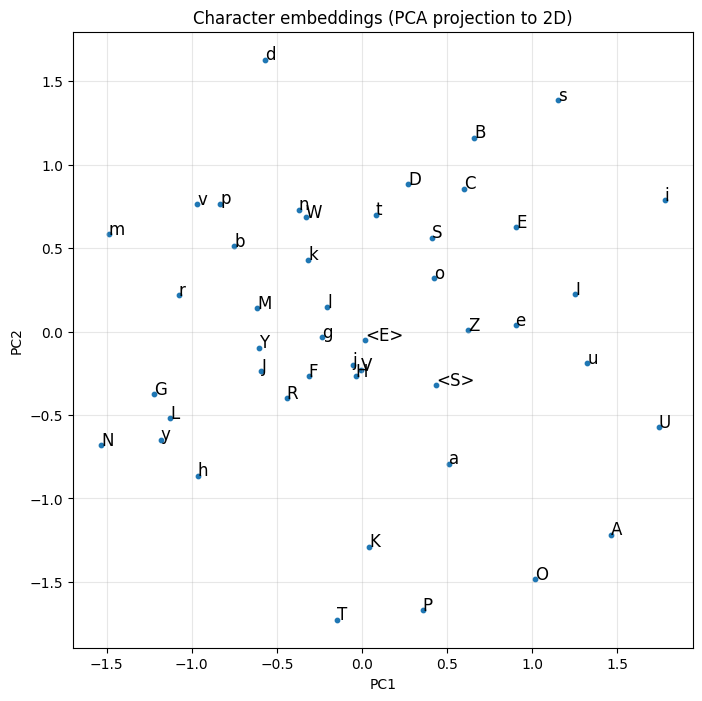

In [9]:
#character embeddings in PCA(Principal Component Analysis)
#We compress our higher dimesniosnal data into fewer dimensions which preserving as much of the meaningful variation as possible.
#When we plot this, we see a structure emerge — e.g., vowels clustering together, characters that play similar roles in names sitting near each other — purely as a side effect of training the model to predict next-characters, something that PCA helps us show by compressing higher dimensional data into fewer more important dimensions which preserve meaningful variation.

def pca_2d(X):
    X_centered = X - X.mean(axis=0)
    cov = np.cov(X_centered.T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = np.argsort(eigvals)[::-1]
    top2 = eigvecs[:, order[:2]]
    return X_centered @ top2

emb_2d = pca_2d(model.C)  # (vocab_size, 2)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.scatter(emb_2d[:, 0], emb_2d[:, 1], s=10)
for i, ch in itos.items():
    label = ch if ch not in (START, END) else ("<S>" if ch == START else "<E>")
    plt.annotate(label, (emb_2d[i, 0], emb_2d[i, 1]), fontsize=12)
plt.title("Character embeddings (PCA projection to 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.show()